In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
#data loading
df = pd.read_csv('data/ifood_df.csv')
df.head(5)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3          2205 non-n

In [4]:
df.isnull().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [5]:
#get columns names as a list
col_names_list = list(df.columns)
print(col_names_list)

['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']


In [6]:
#defining the target and the features
y = df['Response']
x = df.drop(['Response'], axis=1)

In [7]:
#data is imbalanced
y.value_counts()

Response
0    1872
1     333
Name: count, dtype: int64

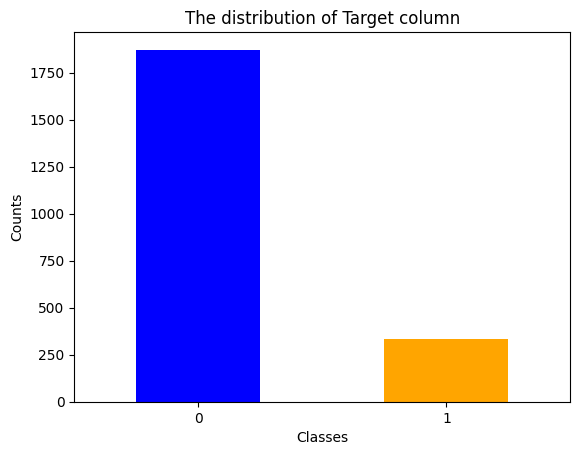

In [8]:
#visualising this 
y.value_counts().plot(kind='bar', color=['blue', 'orange'])

plt.title('The distribution of Target column')
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.xticks(ticks=[0, 1], labels=['0', '1'], rotation=0)
plt.show()

In [9]:
#Creating the model with imbalanced values
#test train split
x_im_train, x_im_test, y_im_train, y_im_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_im_train, y_im_train)
y_pred_randomforest_im = model.predict(x_im_test)

print(f1_score(y_im_test, y_pred_randomforest_im))
print('------------------------------')
print(classification_report(y_im_test, y_pred_randomforest_im))

0.42424242424242425
------------------------------
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       374
           1       0.66      0.31      0.42        67

    accuracy                           0.87       441
   macro avg       0.77      0.64      0.68       441
weighted avg       0.85      0.87      0.85       441



In [11]:
# print(f"scikit-learn version: {sklearn.__version__}")
print(f"imbalanced-learn version: {imblearn.__version__}")

imbalanced-learn version: 0.14.1


In [12]:
#Balancing the dataset using SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

print('X.shape ', x.shape)
print('Y.shape', y.shape)
print('X_resampled.shape', x_resampled.shape)
print('Y_resampled.shape', y_resampled.shape)

X.shape  (2205, 38)
Y.shape (2205,)
X_resampled.shape (3744, 38)
Y_resampled.shape (3744,)


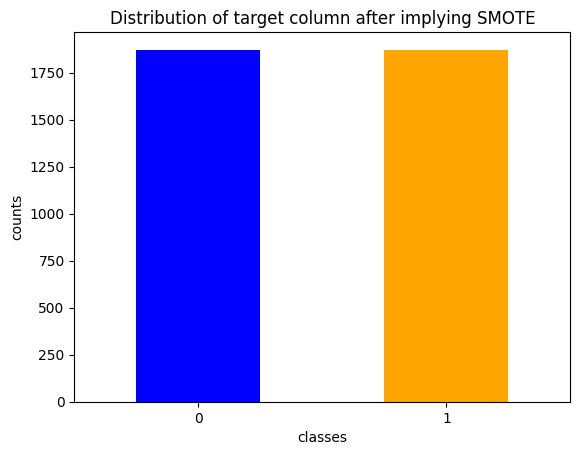

In [13]:
#ploting the distribution, after using smote to handle the imbalancement 
y_resampled.value_counts().plot(kind='bar', color=['blue', 'orange'])

plt.xlabel('classes')
plt.ylabel('counts')
plt.title('Distribution of target column after implying SMOTE')
plt.xticks(ticks=[0,1], labels=['0','1'], rotation=0)

plt.show()

In [14]:
#test train split after SMOTE
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)

In [15]:
#Catboost classifier
model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
model.fit(x_train, y_train)
y_pred_cat = model.predict(x_test)

#RandomForest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred_randomforest = model.predict(x_test)

#XG boost classifier
model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred_xgboost = model.predict(x_test)

# Lightgbm classifier
model = LGBMClassifier()
model.fit(x_train, y_train)
y_pred_lgbm = model.predict(x_test)

# K-nearest Neighbors
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)
y_pred_knn = model.predict(x_test)

# Gaussian Naive Bayes classifier
model = GaussianNB()
model.fit(x_train, y_train)
y_pred_nb = model.predict(x_test)

# Adaboost classifier
model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred_ada = model.predict(x_test)

0:	learn: 0.6386921	total: 114ms	remaining: 1m 53s
100:	learn: 0.1155743	total: 359ms	remaining: 3.19s
200:	learn: 0.0553939	total: 565ms	remaining: 2.24s
300:	learn: 0.0345788	total: 765ms	remaining: 1.78s
400:	learn: 0.0241468	total: 995ms	remaining: 1.49s
500:	learn: 0.0191317	total: 1.24s	remaining: 1.23s
600:	learn: 0.0161986	total: 1.46s	remaining: 973ms
700:	learn: 0.0144134	total: 1.69s	remaining: 723ms
800:	learn: 0.0135824	total: 1.91s	remaining: 476ms
900:	learn: 0.0132762	total: 2.11s	remaining: 232ms
999:	learn: 0.0130199	total: 2.3s	remaining: 0us
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1500, number of negative: 1495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2470
[LightGBM] [Info] Number of data points in the train set: 2995, number of used features

In [16]:
print('CatBoost F1 Score:', f1_score(y_test, y_pred_cat))
print('----------------------------')
print('Random Forest F1 Score:', f1_score(y_test, y_pred_randomforest))
print('----------------------------')
print('XGBoost F1 Score:', f1_score(y_test, y_pred_xgboost))
print('----------------------------')
print('LightGBM F1 Score:', f1_score(y_test, y_pred_lgbm))
print('----------------------------')
print('K-Nearest Neighbors F1 Score:', f1_score(y_test, y_pred_knn))
print('----------------------------')
print('Gaussian Naive Bayes F1 Score:', f1_score(y_test, y_pred_nb))
print('----------------------------')
print('AdaBoost F1 Score:', f1_score(y_test, y_pred_ada))

CatBoost F1 Score: 0.9389920424403183
----------------------------
Random Forest F1 Score: 0.9447368421052632
----------------------------
XGBoost F1 Score: 0.9451137884872824
----------------------------
LightGBM F1 Score: 0.9451137884872824
----------------------------
K-Nearest Neighbors F1 Score: 0.8196319018404908
----------------------------
Gaussian Naive Bayes F1 Score: 0.6484149855907781
----------------------------
AdaBoost F1 Score: 0.8985507246376812


In [17]:
models = ['catboost', 'randomforest', 'xgboost', 'lightgbm', 'knn', 'gaussian nb', 'adaboost']
f1_scores = [f1_score(y_test, y_pred_cat), f1_score(y_test, y_pred_randomforest), f1_score(y_test, y_pred_xgboost), 
            f1_score(y_test, y_pred_lgbm), f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_nb), f1_score(y_test, y_pred_ada)]

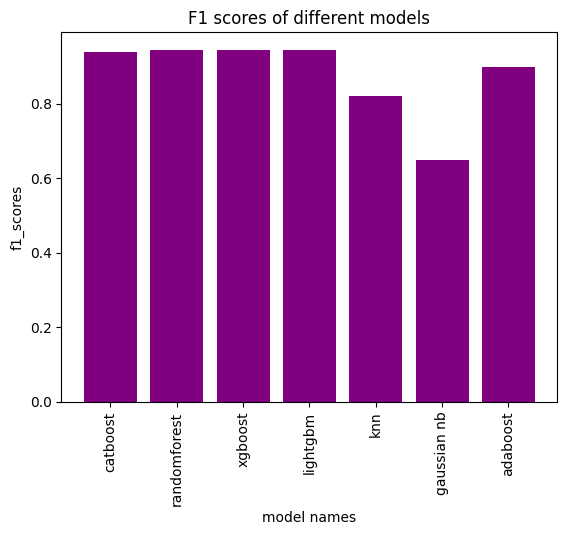

In [20]:
plt.bar(models, f1_scores, color='purple')

plt.title('F1 scores of different models')
plt.xlabel('model names')
plt.ylabel('f1_scores')
plt.xticks(ticks=models, labels=models, rotation=90)

plt.savefig('images/f1_scores.png')

plt.show()